In [ ]:
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_tripp_uncorrected_chi2_only.csv")
y = df["residuals"]

all_features = [
    "ZTF_x1",
    "ZTF_c",
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

short_names = {
    "ZTF_x1": "x₁",
    "ZTF_c": "c",
    "DESI_FASTSPEC_LOGMSTAR": "logM★",
    "DESI_FASTSPEC_SFR": "SFR",
    "DESI_FASTSPEC_VDISP": "σ_v",
    "DESI_FASTSPEC_DN4000": "Dn4000",
    "DESI_FASTSPEC_g_minus_r": "g−r",
    "DESI_FASTSPEC_AGE": "Age",
    "DESI_METADATA_Z": "z"
}

best_params = {
    'n_estimators': 900, 'max_depth': 14, 'min_samples_split': 16,
    'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True,
    'max_samples': 0.801423245872187, 'n_jobs': -1, 'random_state': 42
}

X = df[all_features]
rf = RandomForestRegressor(**best_params)
rf.fit(X, y)

importances = pd.Series(
    rf.feature_importances_,
    index=[short_names[f] for f in all_features]
).sort_values(ascending=False)

print("Feature Importances (MDI):")
print(importances)

Feature Importances (MDI):
c         0.703311
x₁        0.197672
z         0.034571
Dn4000    0.015584
g−r       0.014378
Age       0.010707
logM★     0.008867
SFR       0.008104
σ_v       0.006806
dtype: float64


Baseline RMS (no ML): 0.3488
Baseline RMS (no ML): 0.1867


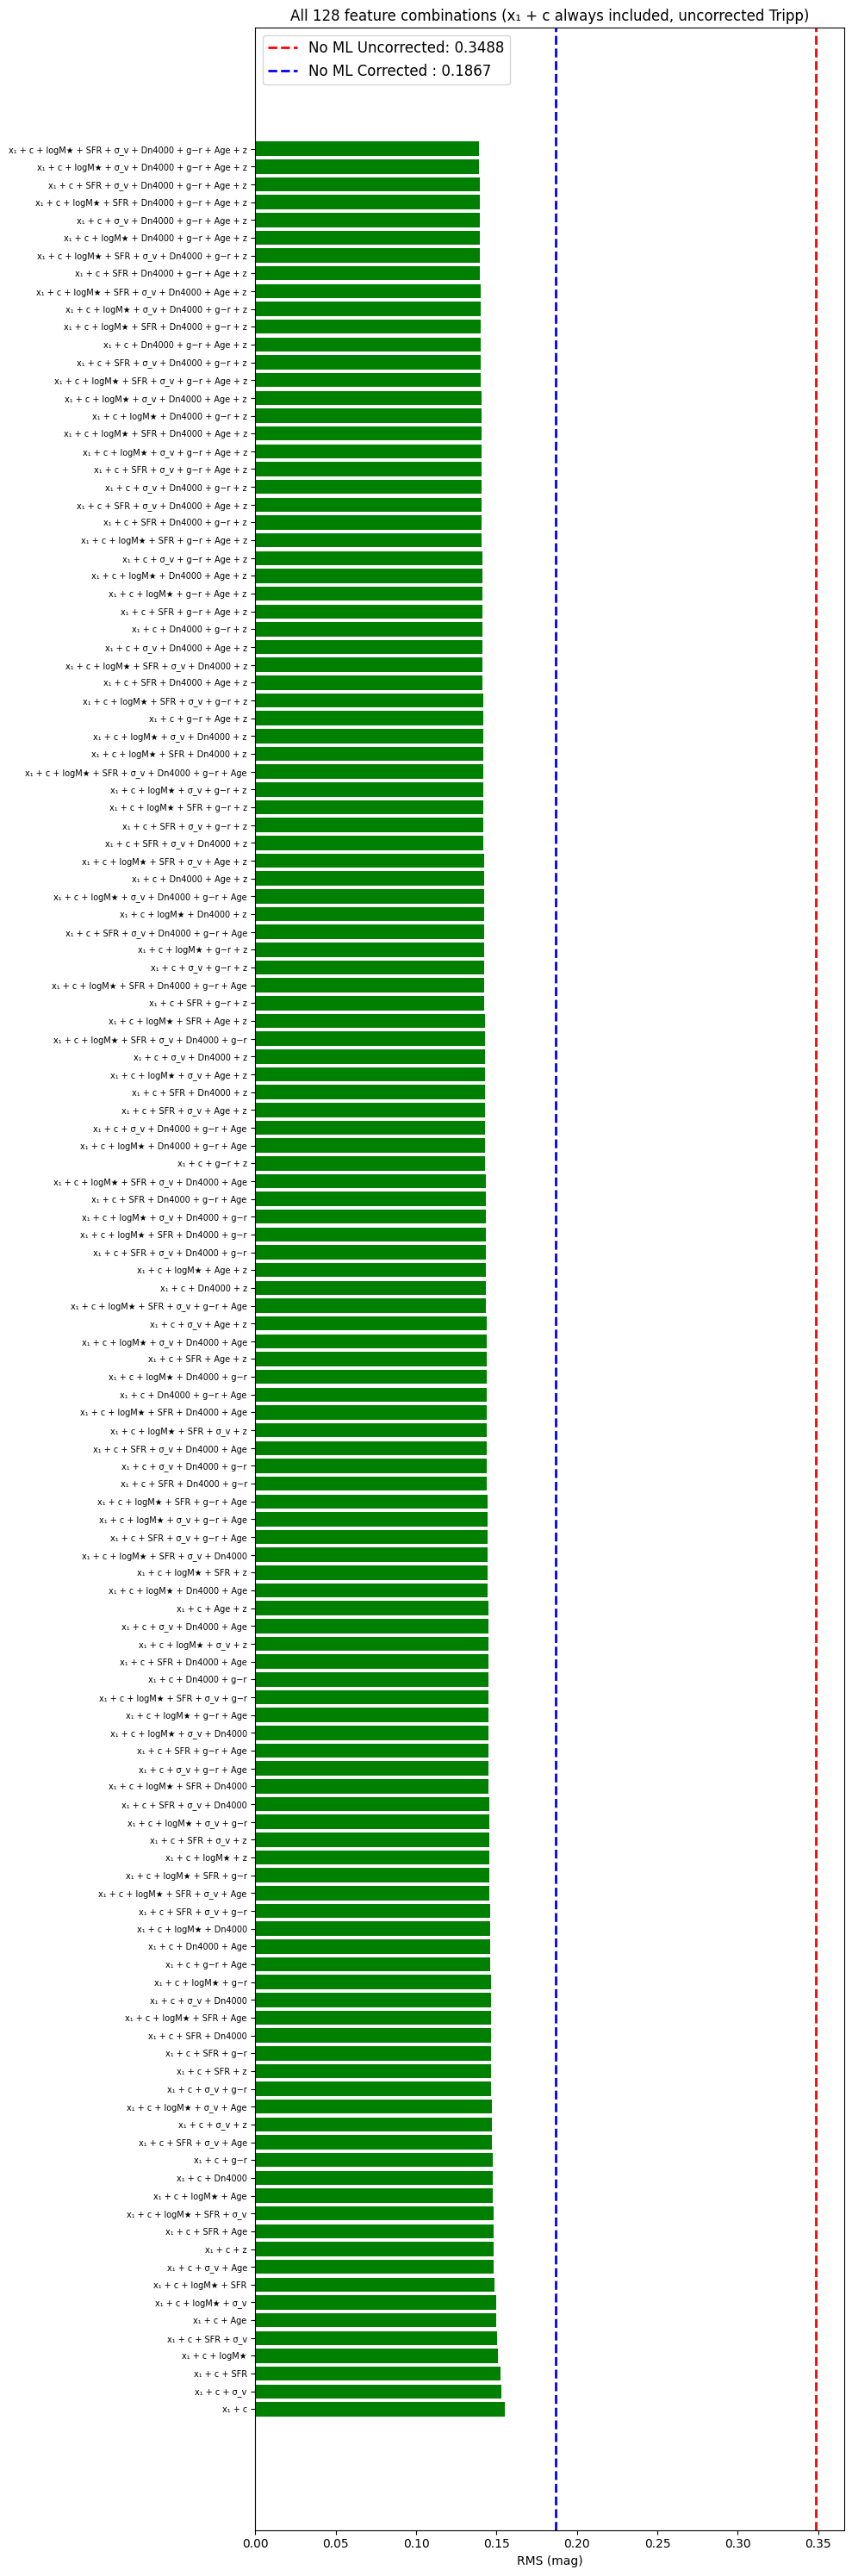

In [2]:
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_tripp_uncorrected_chi2_only.csv")
y = df["residuals"]

# Baseline: RMS with no ML correction
rms_baseline = np.sqrt(np.mean(df["residuals"] ** 2))
print(f"Baseline RMS (no ML): {rms_baseline:.4f}")
print(f"Baseline RMS (no ML): 0.1867")


best_params = {
    'n_estimators': 900, 'max_depth': 14, 'min_samples_split': 16,
    'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True,
    'max_samples': 0.801423245872187, 'n_jobs': -1, 'random_state': 42
}

# x1 and c always included — light-curve params only
fixed_features = ["ZTF_x1", "ZTF_c"]

optional_features = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

short_names = {
    "ZTF_x1": "x₁",
    "ZTF_c": "c",
    "DESI_FASTSPEC_LOGMSTAR": "logM★",
    "DESI_FASTSPEC_SFR": "SFR",
    "DESI_FASTSPEC_VDISP": "σ_v",
    "DESI_FASTSPEC_DN4000": "Dn4000",
    "DESI_FASTSPEC_g_minus_r": "g−r",
    "DESI_FASTSPEC_AGE": "Age",
    "DESI_METADATA_Z": "z"
}

results = []

for n_opt in range(0, len(optional_features) + 1):
    for combo in combinations(optional_features, n_opt):
        combo_list = fixed_features + list(combo)

        params = best_params.copy()
        if params["max_features"] is None and len(combo_list) < 3:
            params["max_features"] = len(combo_list)

        X_combo = df[combo_list]
        rf = RandomForestRegressor(**params)
        rf.fit(X_combo, y)
        y_pred_combo = rf.predict(X_combo)

        corrected_residuals = df["residuals"] - y_pred_combo
        rms = np.sqrt(np.mean(corrected_residuals ** 2))

        label = " + ".join([short_names[f] for f in combo_list])
        results.append({"features": label, "n_features": len(combo_list), "rms": rms})

results_df = pd.DataFrame(results).sort_values("rms", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 30))

colors = ["green" if r < rms_baseline else "gray" for r in results_df["rms"]]
ax.barh(range(len(results_df)), results_df["rms"], color=colors)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df["features"], fontsize=7)
ax.axvline(rms_baseline, color="red", linestyle="--", linewidth=2, label=f"No ML Uncorrected: {rms_baseline:.4f}")
ax.axvline(0.1867, color="blue", linestyle="--", linewidth=2, label=f"No ML Corrected : 0.1867")
ax.set_xlabel("RMS (mag)")
ax.set_title("All 128 feature combinations (x₁ + c always included, uncorrected Tripp)")
ax.legend(fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.show()